# Методы обработки и распознавания изображений 

## Практическое занятие 4: Реализация многослойных нейронных сетей

<h2 style="text-align: center;"><b>Реализация одного нейрона на PyTorch</b></h2>

Рассмотрим особенности программирования нейронных сетей на фреймворке PyTorch, начнем с самого простого - как написать свой нейрон с разными функциями потерь и рассмотрим его работу на конкретных датасетах.

<h3 style="text-align: center;"><b>Компоненты нейросети</b></h3>

При построении любой ***нейронной сети*** для нас важна:  

- непосредственно, сама **архитектура** нейросети (сюда входят типы функций активации у каждого нейрона);
- начальная **инициализация** весов каждого слоя;
- метод **оптимизации** нейросети (сюда ещё входит метод изменения `learning_rate`);
- размер **батчей** (`batch_size`);
- количество **эпох** обучения (`num_epochs`);
- **функция потерь** (`loss`);  
- тип **регуляризации** нейросети (для каждого слоя можно свой);  

То, что связано с ***данными и задачей***:  
- само **качество** выборки (непротиворечивость, чистота, корректность постановки задачи);  
- **размер** выборки;  

<h3 style="text-align: center;"><b>Один нейрон на PyTorch</b></h3>

Импорты

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)

Синтетические Яблоки и груши

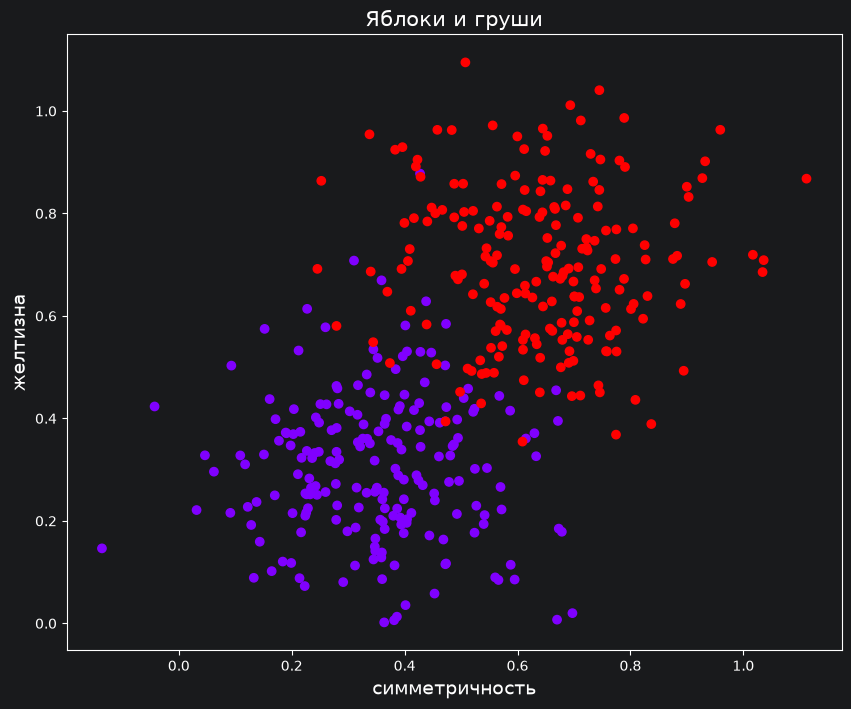

In [22]:
n = 200
apples = np.random.randn(n, 2) * 0.15 + np.array([0.35, 0.30])
pears  = np.random.randn(n, 2) * 0.15 + np.array([0.65, 0.70])

X_np = np.vstack([apples, pears]).astype(np.float32)
y_np = np.hstack([np.zeros(n), np.ones(n)]).astype(np.float32)

data = pd.DataFrame(X_np, columns=['симметричность', 'желтизна'])
data['target'] = y_np

plt.figure(figsize=(10, 8))
plt.scatter(data['симметричность'], data['желтизна'],c=data['target'], cmap='rainbow')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show()

Обучение одного нейрона

loss = tensor(16.7843)


C:\Users\vladi.DESKTOP-UDNKC5A\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\nn\modules\loss.py:48: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


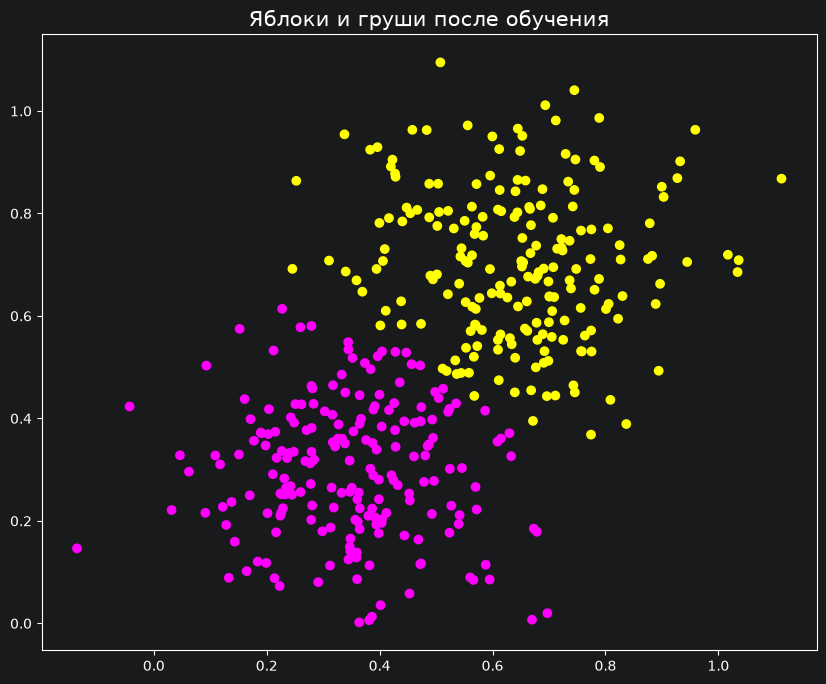

In [23]:
X = torch.autograd.Variable(torch.FloatTensor(data.iloc[:, :2].values))
y = torch.autograd.Variable(torch.FloatTensor(data['target'].values.reshape(-1, 1)))

neuron = nn.Sequential(nn.Linear(2, 1),nn.Sigmoid())

loss_fn = nn.MSELoss(size_average=False)
optimizer = torch.optim.SGD(neuron.parameters(), lr=0.01)

for t in range(500):
    y_pred = neuron(X)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print('loss =', loss.data)

# визуализация
y_pred = (neuron(X) > 0.5).data.numpy().reshape(-1)
plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=y_pred, cmap='spring')
plt.title('Яблоки и груши после обучения', fontsize=15)
plt.show()

Генерация спирали

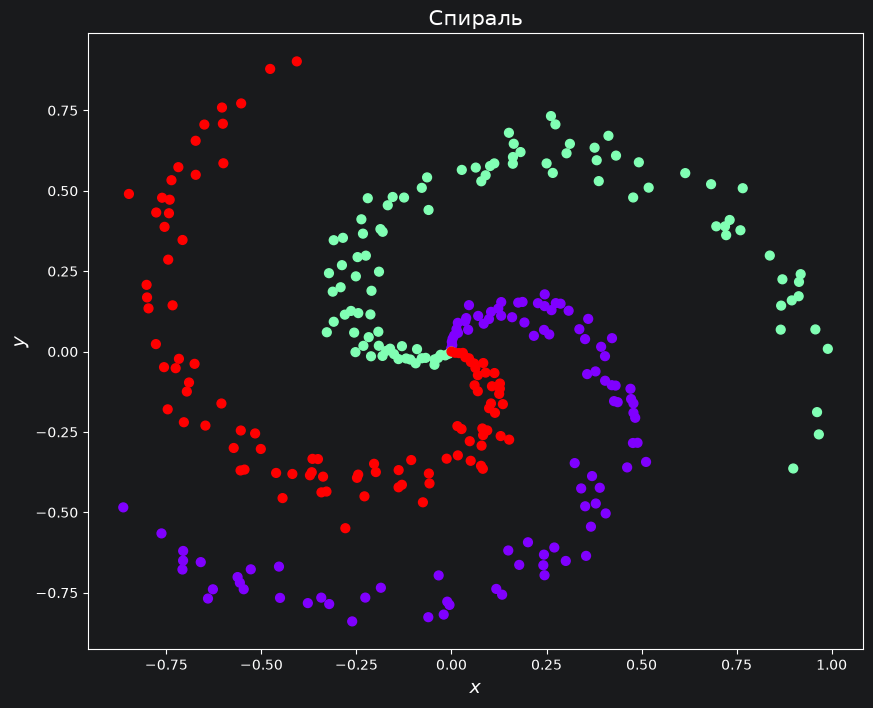

In [24]:
N, D, K = 100, 2, 3
X_sp = np.zeros((N * K, D))
y_sp = np.zeros(N * K, dtype='uint8')

for j in range(K):
    ix = range(N * j, N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2
    X_sp[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y_sp[ix] = j

plt.figure(figsize=(10, 8))
plt.scatter(X_sp[:, 0], X_sp[:, 1], c=y_sp, s=40, cmap=plt.cm.rainbow)
plt.title('Спираль', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show()

X_sp = torch.autograd.Variable(torch.FloatTensor(X_sp))
y_sp = torch.autograd.Variable(torch.LongTensor(y_sp.astype(np.int64)))

Линейная модель

loss = tensor(226.3759)


C:\Users\vladi.DESKTOP-UDNKC5A\AppData\Local\Temp\ipykernel_10924\2326443259.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(X_sp[:, 0].min()-1, X_sp[:, 0].max()+1, h), np.arange(X_sp[:, 1].min()-1, X_sp[:, 1].max()+1, h))


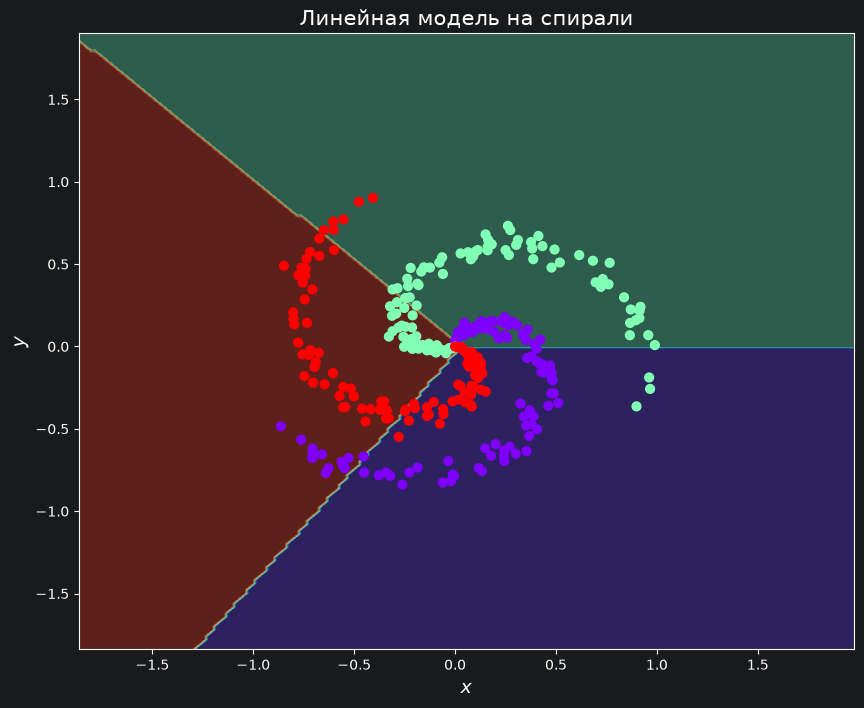

In [25]:
linear = nn.Sequential(nn.Linear(2, 3))

loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.SGD(linear.parameters(), lr=1e-2)

for t in range(1000):
    y_pred = linear(X_sp)
    loss = loss_fn(y_pred, y_sp)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print('loss =', loss.data)

h = 0.02
xx, yy = np.meshgrid(np.arange(X_sp[:, 0].min()-1, X_sp[:, 0].max()+1, h), np.arange(X_sp[:, 1].min()-1, X_sp[:, 1].max()+1, h))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
Z = np.argmax(linear(grid).data.numpy(), axis=1).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X_sp[:, 0], X_sp[:, 1], c=y_sp, s=40, cmap=plt.cm.rainbow)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Линейная модель на спирали', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show()

Двухслойная сеть

loss = tensor(47.1577)


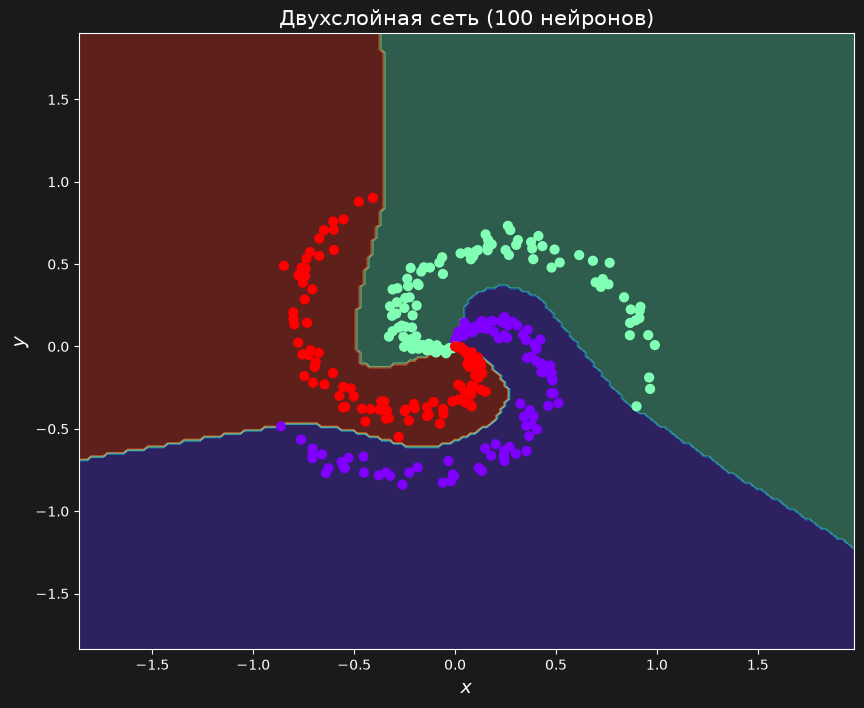

In [26]:
two_layer = nn.Sequential(nn.Linear(2, 100),nn.ReLU(),nn.Linear(100, 3),)

loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.SGD(two_layer.parameters(), lr=1e-3)

for t in range(1000):
    y_pred = two_layer(X_sp)
    loss = loss_fn(y_pred, y_sp)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print('loss =', loss.data)

Z = np.argmax(two_layer(grid).data.numpy(), axis=1).reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X_sp[:, 0], X_sp[:, 1], c=y_sp, s=40, cmap=plt.cm.rainbow)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Двухслойная сеть (100 нейронов)', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show()

better_net

loss = tensor(9.9924)


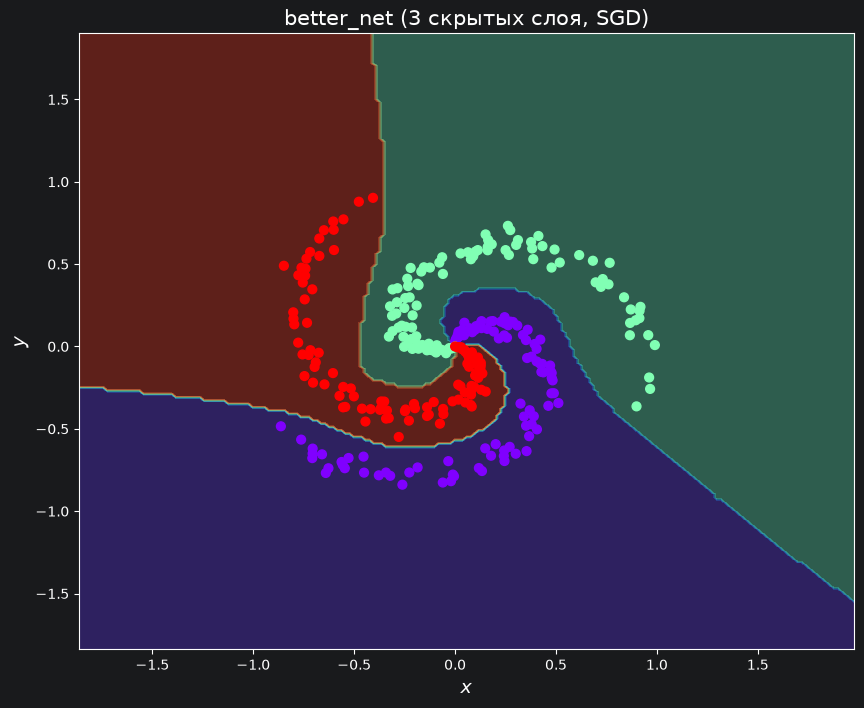

In [27]:
better_net = nn.Sequential(nn.Linear(2, 100), nn.ReLU(),nn.Linear(100, 100), nn.ReLU(),nn.Linear(100, 100), nn.ReLU(),nn.Linear(100, 3))

loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.SGD(better_net.parameters(), lr=1e-3)

for t in range(600):
    y_pred = better_net(X_sp)
    loss = loss_fn(y_pred, y_sp)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print('loss =', loss.data)

Z = np.argmax(better_net(grid).data.numpy(), axis=1).reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X_sp[:, 0], X_sp[:, 1], c=y_sp, s=40, cmap=plt.cm.rainbow)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('better_net (3 скрытых слоя, SGD)', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show()

## Дополнительное задание

loss = tensor(10.4427)


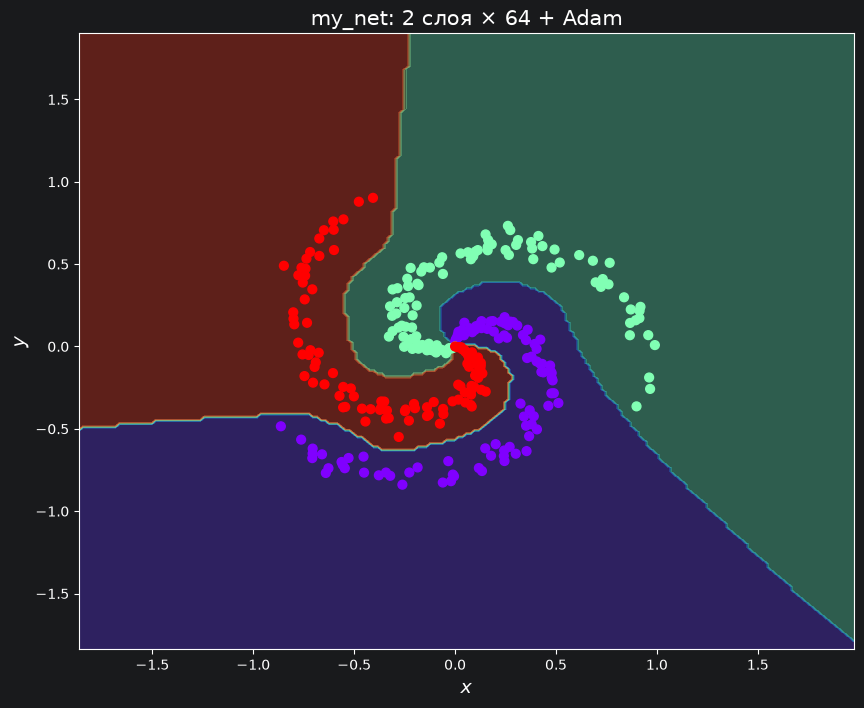

In [28]:
my_net = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 3))

loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(my_net.parameters(), lr=1e-3)

for t in range(800):
    y_pred = my_net(X_sp)
    loss = loss_fn(y_pred, y_sp)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print('loss =', loss.data)

Z = np.argmax(my_net(grid).data.numpy(), axis=1).reshape(xx.shape)
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X_sp[:, 0], X_sp[:, 1], c=y_sp, s=40, cmap=plt.cm.rainbow)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('my_net: 2 слоя × 64 + Adam', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show()